# DBSCAN 聚类实战：虚拟城市人口分布分析

## 1. 案例背景

在本次实战中，我们将模拟一个城市的地理空间数据。假设我们收集了城市中不同区域的人口分布点，数据包含以下特征：
- **高密度中心城区**：类似于商业区或密集住宅区，呈现团状分布。
- **沿河/沿路居住带**：沿着河流或主干道分布，呈现非凸的长条或弯曲形状。
- **稀疏郊区/噪声**：散落在城市周边的零星住户。

我们的目标是使用 **DBSCAN** 算法自动识别出这些主要的功能区（簇），并将其与传统的 **K-Means** 算法进行对比，展示 DBSCAN 在处理非凸形状和抗噪方面的优势。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

# 设置随机种子以保证结果可复现
np.random.seed(42)
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 数据生成

我们构造一个包含三种结构的合成数据集：

总数据点数: 850


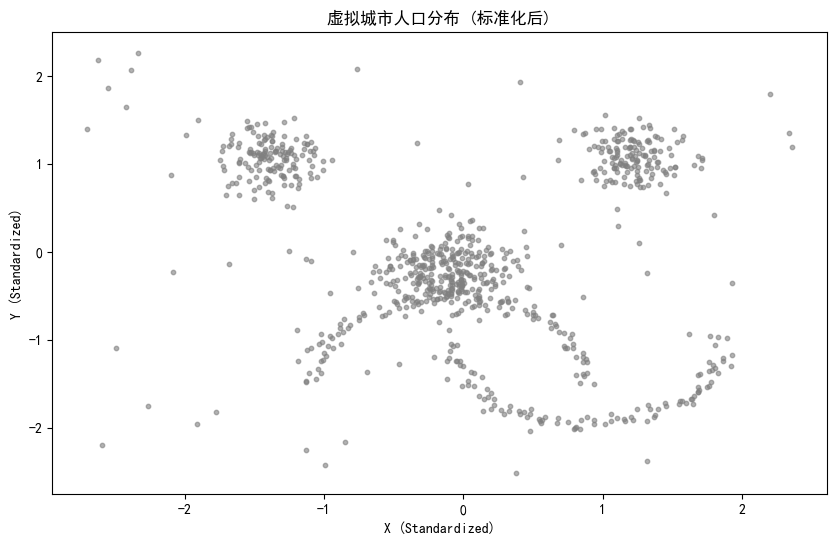

In [2]:
# 1. 城市中心 (高密度，团状)
centers = [[0, 0], [2, 2], [-2, 2]]
X_city, _ = make_blobs(n_samples=[300, 150, 150], centers=centers, cluster_std=[0.4, 0.3, 0.3], random_state=42)

# 2. 河流/公路 (非凸形状，弯曲)
X_river, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
X_river = X_river * 1.5 + np.array([0, -2]) # 调整位置和大小

# 3. 稀疏郊区/噪声 (均匀分布)
n_noise = 50
X_noise = np.random.uniform(low=-4, high=4, size=(n_noise, 2))

# 合并所有数据
X = np.vstack([X_city, X_river, X_noise])
print(f"总数据点数: {X.shape[0]}")

# 数据标准化 (对于基于距离的算法至关重要)
X_scaled = StandardScaler().fit_transform(X)

# 可视化原始数据
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=10, c='gray', alpha=0.6)
plt.title("虚拟城市人口分布 (标准化后)")
plt.xlabel("X (Standardized)")
plt.ylabel("Y (Standardized)")
plt.show()

## 3. K-Means 聚类效果

首先，让我们看看 K-Means 算法的表现。假设我们知道大致有 4 个主要区域。

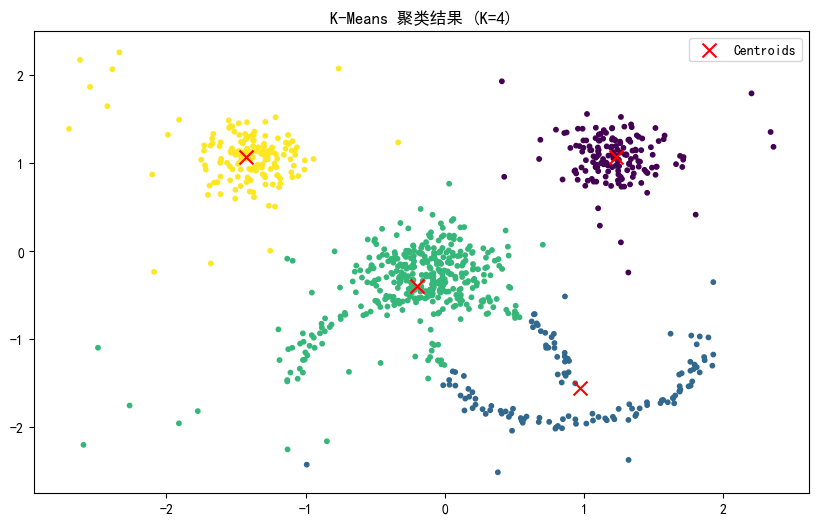

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, s=10, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red', marker='x', label='Centroids')
plt.title("K-Means 聚类结果 (K=4)")
plt.legend()
plt.show()

**观察**：
可以看到 K-Means 的典型缺陷：
1.  **无法处理非凸形状**：底部的“河流/公路”带被切成了两段（分别归属了不同的簇），这显然不符合地理逻辑。
2.  **对噪声敏感**：周围的稀疏噪声点被强制归入了最近的簇，导致簇的边界被不合理地拉大。

## 4. DBSCAN 参数选择 (k-distance graph)

DBSCAN 需要两个参数：`eps` 和 `min_samples`。我们可以使用 k-距离图来辅助选择 `eps`。
一般来说，`min_samples` 可以设置为 `2 * dim`，这里维度是 2，所以我们选 `min_samples=4` 或 `5`。

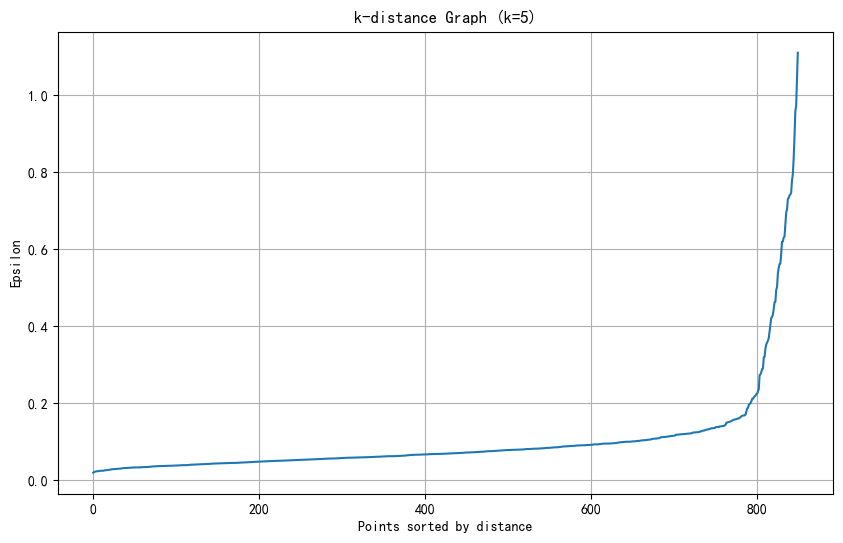

In [4]:
from sklearn.neighbors import NearestNeighbors

# 计算每个点到其第 k 个最近邻居的距离
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 排序距离
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title("k-distance Graph (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()

**分析**：
观察上图的“肘部”（Elbow），即曲线曲率最大的地方。这个位置对应的 y 轴数值通常是一个不错的 `eps` 起点。
从图中看（根据生成数据的经验），肘部大约在 `0.2` 到 `0.3` 之间。我们将尝试 `eps=0.3`。

## 5. DBSCAN 聚类效果

发现的簇数量: 3
噪声点数量: 35


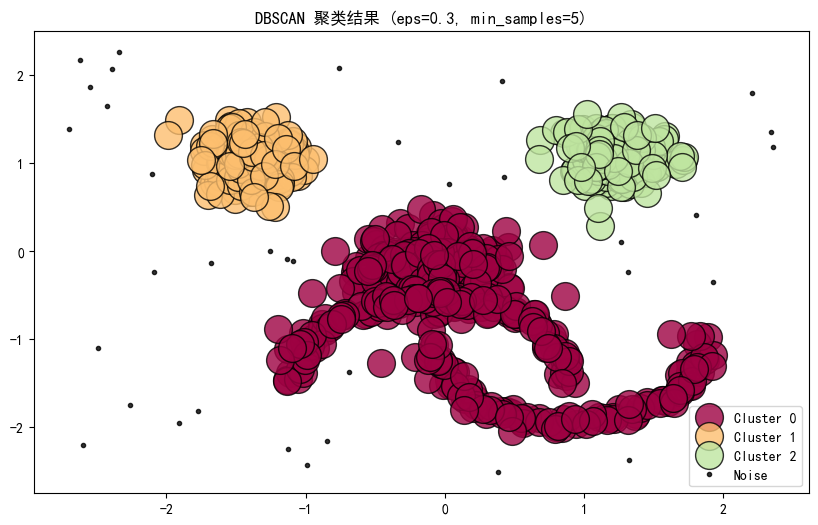

In [5]:
# 运行 DBSCAN
db = DBSCAN(eps=0.3, min_samples=5)
db.fit(X_scaled)
y_db = db.labels_

# 统计结果
n_clusters_ = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)

print(f"发现的簇数量: {n_clusters_}")
print(f"噪声点数量: {n_noise_}")

# 可视化
plt.figure(figsize=(10, 6))
unique_labels = set(y_db)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # 黑色用于表示噪声
        col = [0, 0, 0, 1]
        label = 'Noise'
        marker = '.'
        size = 10
    else:
        label = f'Cluster {k}'
        marker = 'o'
        size = 20

    class_member_mask = (y_db == k)
    
    xy = X_scaled[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], marker, markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=size if k != -1 else 6, 
             alpha=0.8, label=label)

plt.title(f"DBSCAN 聚类结果 (eps=0.3, min_samples=5)")
plt.legend()
plt.show()

## 6. 总结

通过对比 K-Means 和 DBSCAN 在这个虚拟城市数据集上的表现，我们可以得出以下结论：

1.  **形状适应性**：DBSCAN 成功识别出了弯曲的“河流/公路”带（作为一个完整的簇），而 K-Means 错误地将其切断。
2.  **噪声处理**：DBSCAN 准确地将散落在周围的稀疏点标记为黑色（噪声），保证了核心簇的纯净度；而 K-Means 被迫将这些点归入最近的簇。
3.  **簇的数量**：我们不需要告诉 DBSCAN 有多少个簇，它自动发现了 3 个主要的密度中心（如果参数调整得当，河流带可能被识别为一个或分开）。

这证明了 DBSCAN 在处理具有复杂几何形状和噪声的现实世界数据（如地理信息、图像分割）时具有显著优势。